# Hard coal NPV simulation

Run the hard coal electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_hard_coal_npv

In [17]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,annual_output_mwh,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,emissions_tco2_per_mwh_e,coal_price_eur_per_mwh_th,electricity_price_eur_per_mwh,carbon_price_eur_per_t,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur
0,0,1000000.0,243.902439,243902.439024,1744.616687,33.182929,4.542639,2.510152,0.869989,12.719659,94.07,1.0,4.255163e+08,94070000.0,8.093397e+06,4.542639e+06,3.192827e+07,869988.848237,4.863570e+07,9.365895e+07
1,1,1000000.0,243.902439,243902.439024,2064.649679,38.847039,5.376533,2.660088,0.899907,14.202588,94.07,1.0,5.035731e+08,94070000.0,9.474888e+06,5.376533e+06,3.778014e+07,899906.737269,4.053853e+07,-7.083332e+07
2,2,1000000.0,243.902439,243902.439024,1781.747401,32.931192,4.951869,2.474066,0.853912,13.143084,94.07,1.0,4.345725e+08,94070000.0,8.031998e+06,4.951869e+06,3.251686e+07,853912.284337,4.771536e+07,7.477826e+07
3,3,1000000.0,243.902439,243902.439024,2283.070754,34.245153,5.087205,2.488286,0.889853,15.452793,94.07,1.0,5.568465e+08,94070000.0,8.352476e+06,5.087205e+06,3.845096e+07,889852.886290,4.128950e+07,-1.160903e+08
4,4,1000000.0,243.902439,243902.439024,1918.128564,41.533234,4.988955,2.607031,0.881647,10.544336,94.07,1.0,4.678362e+08,94070000.0,1.013006e+07,4.988955e+06,2.748941e+07,881647.270001,5.057993e+07,7.209323e+07


In [18]:
npv_million_eur = results["npv_eur"] / 1_000_000

summary = npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).to_frame(
    name="NPV million EUR"
)
summary

,NPV million EUR
count,1000000.000000
mean,20.472600
std,76.923994
min,-363.900954
5%,-115.941729
50%,25.897484
95%,138.008236
max,223.622315


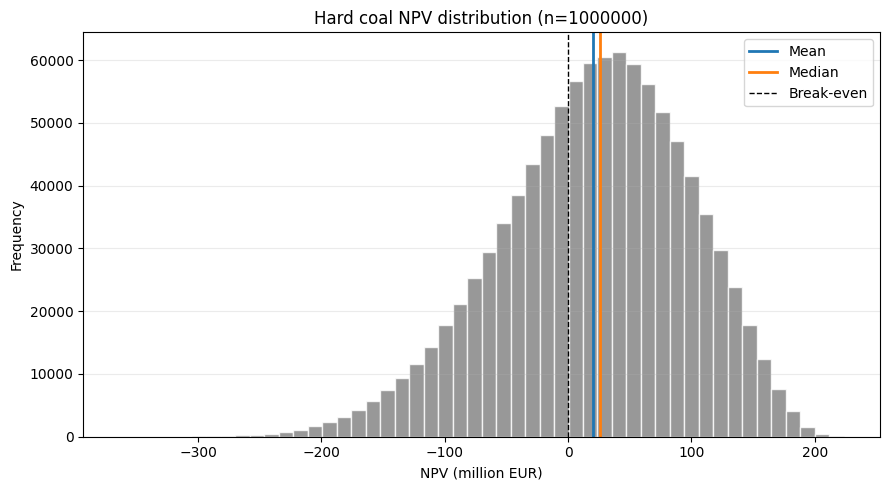

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [20]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.325604
annual_variable_opex_eur      5.165982
annual_fuel_cost_eur         31.089455
annual_emissions_cost_eur     0.873336
annual_net_cash_flow_eur     47.615623
Name: Mean annual value, million EUR, dtype: float64